In [2]:
# Latex macros -- ignore
from IPython.display import display, Math
with open('macros.tex', 'r') as f:
        macros = f.read()
display(Math(macros))

<IPython.core.display.Math object>

In [3]:
from IPython.display import Latex
def showState(label, state):
    stateSource = state.draw("latex_source")
    display(Latex(label + " $= " + stateSource + "$"))

# Quantum Circuits
* Quantum computing is about building circuits.
* Just like classical computing has NAND gate as a universal gate, there are various set of gates that are universal for quantum computing.
    * CNOT gate and single qubit gates are universal.
    * Any single qubit gate can be approximated efficiently within desired precision.
* Now, we'll start creating circuits.

## Creating Quantum circuits in qiskit

# Hadamard gate
$H = \frac{1}{\sqrt{2}}\begin{bmatrix}1 & 1\\ 1 & -1\end{bmatrix}$

<IPython.core.display.Latex object>

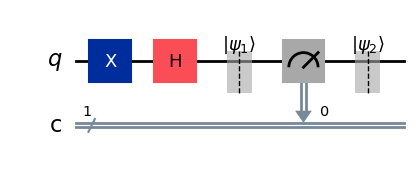

Measurement Outcome 0


<IPython.core.display.Latex object>

In [16]:
from qiskit import QuantumCircuit # circuit
from qiskit.quantum_info import Statevector # quantum states

qc = QuantumCircuit(1, 1) # One qubit, one classical bit for measurement outcome. qubit initialized to |0>

qc.x(0)
qc.h(0) # Add a hadamard gate to qubit 0

# display(qc.draw("mpl"))
psi1L = r"$|\psi_1\rangle $"
qc.barrier(label=psi1L)

psi1 = Statevector(qc) # Compute the current quantum state

showState(psi1L, psi1)

qc.measure(0, 0) # Add measure gate on qubit 0 and store the outcome on classical bit 0

psi2L = r"$|\psi_2\rangle $"
qc.barrier(label=psi2L)

display(qc.draw("mpl"))

outcome, psi2 = psi1.measure() # ideal measurement ket_measured is state after measurement

print('Measurement Outcome', outcome)

display(psi2.draw("latex"))

## Exercise 
* Create following states in composer
    * $(\ket{0} - i\ket{1})/\sqrt{2}$
    * $(-\ket{0} + \ket{1})/\sqrt{2}$
    * $(\ket{0} + i\ket{1})/\sqrt{2}$
* Show the following
    * $XYX = -Y$
    * $XZX = -Z$
    * $HZH = X$
    * $SXS^\dagger = Y$

## Creating entangled states
* Bell states are 
$$\begin{align*}
|\beta_{00}\rangle &= \frac{1}{\sqrt{2}}\left[|00\rangle + |11\rangle\right]\\
|\beta_{01}\rangle &= \frac{1}{\sqrt{2}}\left[|01\rangle + |10\rangle\right]\\
|\beta_{10}\rangle &= \frac{1}{\sqrt{2}}\left[|00\rangle - |11\rangle\right]\\
|\beta_{11}\rangle &= \frac{1}{\sqrt{2}}\left[|10\rangle - |10\rangle\right]\\
\end{align*}$$
* We can obtain these states using the following operations
$$\begin{align*}
|a\rangle|b\rangle \xrightarrow{H(0)} |\cdot\rangle\xrightarrow{CNOT(0,1)} |\beta_{ab}\rangle
\end{align*}$$
as constructed by the circuit below.
$$
\begin{align*}
|0\rangle|0\rangle &\xrightarrow{H(0)} \left[\frac{|0\rangle + |1\rangle}{\sqrt{2}}\right]|0\rangle\\
&= \frac{1}{\sqrt{2}}(|00\rangle + |10\rangle)\\
&\xrightarrow{CNOT(0, 1)}\frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)
\end{align*}
$$

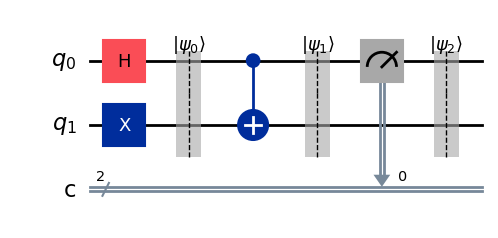

Circuit states:


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

qc = QuantumCircuit(2, 2) 

# qc.x(0)
qc.x(1)
qc.h(0)


psi0L = r"$|\psi_0\rangle $"
qc.barrier(label=psi0L)
psi0 = Statevector(qc) # Compute the current quantum state


# display(psi0.draw("latex"))
###########################################

qc.cx(0, 1) # Add controlled-not gate with control at 0 and target 1

psi1L = r"$|\psi_1\rangle $"
qc.barrier(label=psi1L)
psi1 = Statevector(qc) # Compute the current quantum state

# display(psi1.draw("latex"))
############################################
qc.measure(0, 0) # Add measure gate on qubit 0 and store the outcome on classical bit 0

psi2L = r"$|\psi_2\rangle $"
qc.barrier(label=psi2L)
display(qc.draw("mpl"))

###################################################
outcome, psi2 = psi1.measure() # ideal measurement ket_measured is state after measurement


print('Circuit states:')

showState(psi0L, psi0)
showState(psi1L, psi1)
showState(psi2L, psi2)
# print('Measurement Outcome', outcome)
# display(psi2.draw("latex"))

## Exercise 
Create following states in composer
* $(-\ket{00} + \ket{11})/\sqrt{2}$
* $(\ket{00}+\ket{01} + \ket{10} - \ket{11})/2$
* $\ket{GHZ} = (\ket{000} + \ket{111})/\sqrt{2}$
* $\ket{W} = (\ket{001} + \ket{100} + \ket{010})/\sqrt{3}$

## Creating a swap operation using CNOT gates
$$\begin{align*}
    |a\rangle|b\rangle &\xrightarrow{CNOT(1,2)}|a\rangle|a\oplus b\rangle\\
                       &\xrightarrow{CNOT(2,1)}|a\oplus a\oplus b\rangle|a\oplus b\rangle=|b\rangle|a\oplus b\rangle\\
                       &\xrightarrow{CNOT(1,2)}|b\rangle|a\oplus b\oplus b\rangle = |b\rangle|a\rangle
\end{align*}$$

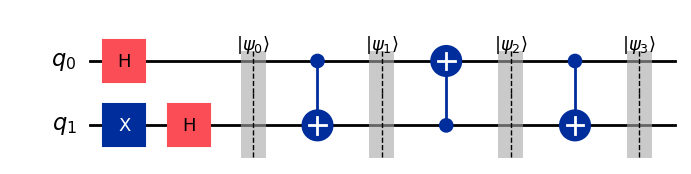

Circuit states:


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [6]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

qc = QuantumCircuit(2)
qc.h(0)
# qc.y(0)
qc.x(1)
qc.h(1)

psi0L = r"$|\psi_0\rangle $"
psi0 = Statevector(qc)
qc.barrier(label=psi0L)

qc.cx(0,1)

psi1L = r"$|\psi_1\rangle $"
psi1 = Statevector(qc)
qc.barrier(label=psi1L)

qc.cx(1,0)

psi2L = r"$|\psi_2\rangle $"
psi2 = Statevector(qc)
qc.barrier(label=psi2L)

qc.cx(0,1)

psi3L = r"$|\psi_3\rangle $"
psi3 = Statevector(qc)
qc.barrier(label=psi3L)

display(qc.draw("mpl"))
print('Circuit states:')
showState(psi0L, psi0)
showState(psi1L, psi1)
showState(psi2L, psi2)
showState(psi3L, psi3)

## Exercise 
Prove the following identities:
* **Flip CNOT**: $(H\otimes H)\cdot CNOT_{01}\cdot(H\otimes H) = CNOT_{10}$
* $(Z\otimes I)\cdot CNOT \cdot (Z\otimes I) = CNOT$
* $(I\otimes X)\cdot CNOT \cdot (I\otimes X) = CNOT$
* $(X\otimes X)\cdot CNOT \cdot (X\otimes I) = CNOT$
* $(Z\otimes Z)\cdot CNOT \cdot (Z\otimes I) = CNOT$
* $(I\otimes H)\cdot CNOT_{01} \cdot (I\otimes H) = CZ_{01}$
* $CR_z(\theta) = R_z(\theta/2)\cdot CNOT\cdot R_z(-\theta/2)\cdot CNOT$
* $CY_{01} = (I\otimes S)\cdot CNOT_{01}\cdot (I\otimes S^\dagger)$

## Constructing single qubit controlled gates
* We saw that qiskit provides a way to get controlled gate.
* Now we provide the mechanism that is used to get the controlled gate for single qubit unitary gate $U$.
* Any single qubit unitary operator can be expressed as $$U = e^{i\alpha}AXBXC$$ where single qubit unitary gates satisfy $$ABC = I$$
    * Proof this fact is based on angle decomposition of $U$.
    * $U = e^{i\alpha}R_z(\beta)R_y(\gamma)R_z(\delta)$
    * $A = R_z(\beta)R_y(\gamma/2)$
    * $B = R_y(-\gamma/2)R_z(-(\delta + \beta)/2)$
    * $C = R_z((\delta-\beta)/2)$
    * The trick of controlled version of $U$ is to convert $X$ gates inside $e^{i\alpha}AXBXC$ to controlled-NOT gates.
* Do all controlled-$U$ gates create entanglement?

## Toffoli gate
* Recall that Toffoli gate is controlled-controlled NOT gate
    * Given state $|a\rangle|b\rangle|c\rangle$, NOT gate is applied to $|c\rangle$ only when $a = b = 1$.
* Toffoli gate can be implemented using Hadamard, phase, controlled-NOT and $\pi/8$ gates.

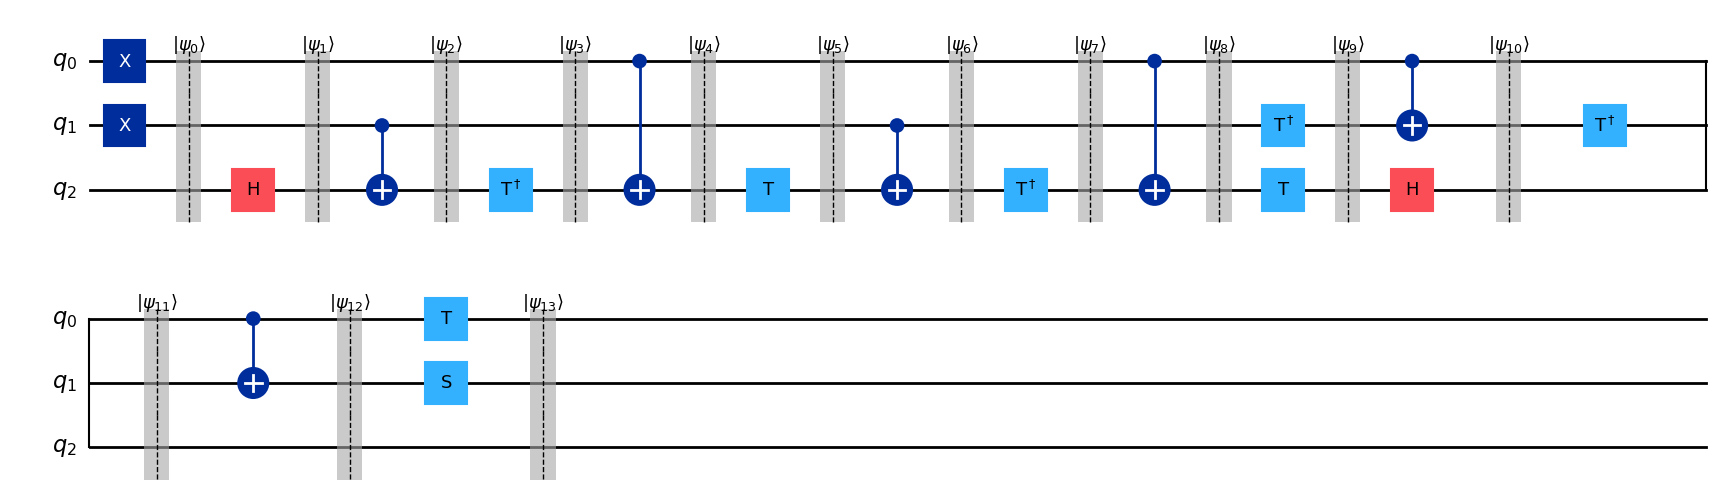

Circuit states:


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

...

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [7]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from numpy import pi
from qiskit.quantum_info import Statevector

qreg_q = QuantumRegister(3, 'q')

circuit = QuantumCircuit(qreg_q)

# circuit.x(qreg_q[2])
circuit.x(qreg_q[1])
circuit.x(qreg_q[0])
psi0L = r"$|\psi_0\rangle $"
psi0 = Statevector(circuit)
circuit.barrier(qreg_q[0], qreg_q[1], qreg_q[2],label=psi0L)
circuit.h(qreg_q[2])
psi1L = r"$|\psi_1\rangle $"
psi1 = Statevector(circuit)
circuit.barrier(qreg_q[0], qreg_q[1], qreg_q[2],label=psi1L)
circuit.cx(qreg_q[1], qreg_q[2])
psi2L = r"$|\psi_2\rangle $"
psi2 = Statevector(circuit)
circuit.barrier(qreg_q[0], qreg_q[1], qreg_q[2],label=psi2L)
circuit.tdg(qreg_q[2])
psi3L = r"$|\psi_3\rangle $"
psi3 = Statevector(circuit)
circuit.barrier(qreg_q[0], qreg_q[1], qreg_q[2],label=psi3L)
circuit.cx(qreg_q[0], qreg_q[2])
psi4L = r"$|\psi_4\rangle $"
psi4 = Statevector(circuit)
circuit.barrier(qreg_q[0], qreg_q[1], qreg_q[2],label=psi4L)
circuit.t(qreg_q[2])
psi5L = r"$|\psi_5\rangle $"
psi5 = Statevector(circuit)
circuit.barrier(qreg_q[0], qreg_q[1], qreg_q[2],label=psi5L)
circuit.cx(qreg_q[1], qreg_q[2])
psi6L = r"$|\psi_6\rangle $"
psi6 = Statevector(circuit)
circuit.barrier(qreg_q[0], qreg_q[1], qreg_q[2],label=psi6L)
circuit.tdg(qreg_q[2])
psi7L = r"$|\psi_7\rangle $"
psi7 = Statevector(circuit)
circuit.barrier(qreg_q[0], qreg_q[1], qreg_q[2],label=psi7L)
circuit.cx(qreg_q[0], qreg_q[2])
psi8L = r"$|\psi_8\rangle $"
psi8 = Statevector(circuit)
circuit.barrier(qreg_q[0], qreg_q[1], qreg_q[2],label=psi8L)
circuit.tdg(qreg_q[1])
circuit.t(qreg_q[2])
psi9L = r"$|\psi_9\rangle $"
psi9 = Statevector(circuit)
circuit.barrier(qreg_q[0], qreg_q[1], qreg_q[2],label=psi9L)
circuit.cx(qreg_q[0], qreg_q[1])
circuit.h(qreg_q[2])
psi10L = r"$|\psi_{10}\rangle $"
psi10 = Statevector(circuit)
circuit.barrier(qreg_q[0], qreg_q[1], qreg_q[2],label=psi10L)
circuit.tdg(qreg_q[1])
psi11L = r"$|\psi_{11}\rangle $"
psi11 = Statevector(circuit)
circuit.barrier(qreg_q[0], qreg_q[1], qreg_q[2],label=psi11L)
circuit.cx(qreg_q[0], qreg_q[1])
psi12L = r"$|\psi_{12}\rangle $"
psi12 = Statevector(circuit)
circuit.barrier(qreg_q[0], qreg_q[1], qreg_q[2],label=psi12L)
circuit.t(qreg_q[0])
circuit.s(qreg_q[1])
psi13L = r"$|\psi_{13}\rangle $"
psi13 = Statevector(circuit)
circuit.barrier(qreg_q[0], qreg_q[1], qreg_q[2],label=psi13L)

display(circuit.draw("mpl"))
print('Circuit states:')
showState(psi0L, psi0)
showState(psi1L, psi1)
showState(psi2L, psi2)
showState(psi3L, psi3)

showState(psi4L, psi4)
showState(psi5L, psi5)
showState(psi6L, psi6)
showState(psi7L, psi7)

showState(psi8L, psi8)
showState(psi9L, psi9)
showState(psi10L, psi10)
showState(psi11L, psi11)

showState(psi10L, psi12)
showState(psi11L, psi13)

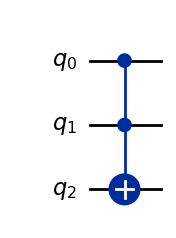

In [8]:
# Qiskit provides the Toffoli gate
from qiskit import QuantumCircuit
qc = QuantumCircuit(3)
qc.ccx(0,1,2)
display(qc.draw('mpl'))

## Using Toffoli gate for multi-controlled gates
* We have seen how to obtain controlled-$U$ gates using decomposition of $U$.
* We can use Toffoli gate along with controlled-$U$ gate to construct multi-controlled-$U$ gate.
* The following circuit implements $C^3-H$ gate. $$|c_1c_2c_3\rangle|w_1w_2\rangle|t\rangle\xrightarrow{C^3-U}|c_1c_2c_3\rangle|w_1w_2\rangle(U^{c_1\cdot c_2\cdot c_3}|t\rangle)$$
* $n$-control requires additional $n-2$ work qubits.
* The key is to store the checks on work qubits.

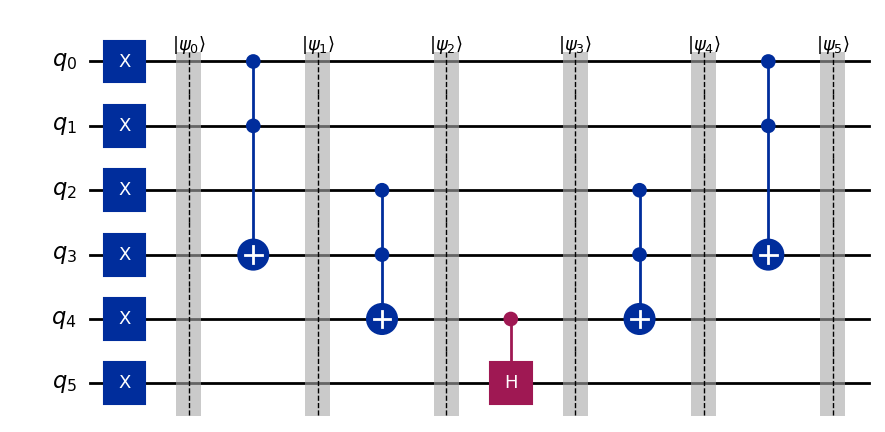

Circuit states:


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

: 

In [ ]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from numpy import pi
from qiskit.quantum_info import Statevector

qreg_q = QuantumRegister(6, 'q')

circuit = QuantumCircuit(qreg_q)
circuit.x([0, 1, 2, 3, 4, 5])
psi0L = r"$|\psi_0\rangle $"
psi0 = Statevector(circuit)
circuit.barrier(qreg_q,label=psi0L)
circuit.ccx(qreg_q[0], qreg_q[1], qreg_q[3])
psi1L = r"$|\psi_1\rangle $"
psi1 = Statevector(circuit)
circuit.barrier(qreg_q,label=psi1L)
circuit.ccx(qreg_q[2], qreg_q[3], qreg_q[4])
psi2L = r"$|\psi_2\rangle $"
psi2 = Statevector(circuit)
circuit.barrier(qreg_q,label=psi2L)
circuit.ch(qreg_q[4], qreg_q[5])
psi3L = r"$|\psi_3\rangle $"
psi3 = Statevector(circuit)
circuit.barrier(qreg_q,label=psi3L)
circuit.ccx(qreg_q[2], qreg_q[3], qreg_q[4])
psi4L = r"$|\psi_4\rangle $"
psi4 = Statevector(circuit)
circuit.barrier(qreg_q,label=psi4L)
circuit.ccx(qreg_q[0], qreg_q[1], qreg_q[3])
psi5L = r"$|\psi_5\rangle $"
psi5 = Statevector(circuit)
circuit.barrier(qreg_q,label=psi5L)

display(circuit.draw('mpl'))
print('Circuit states:')
showState(psi0L, psi0)
showState(psi1L, psi1)
showState(psi2L, psi2)
showState(psi3L, psi3)

showState(psi4L, psi4)
showState(psi5L, psi5)